# Лабораторная работа №7
  
## Тема: Классификация (Байесовские методы, деревья)
  
## Цель работы: Ознакомиться с методами классификации модуля Sklearn.

**Студент:** Магомедов Имран Борисович  
**Группа:** ПИЖ-Б-О-22-1  
**Курс/Семестр:** 4/8  

## Методика и порядок выполнения работы

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, ComplementNB, BernoulliNB
from sklearn import tree
from sklearn.metrics import accuracy_score

### Загрузка данных

2. Загрузка данных

In [2]:
data = pd.read_csv('/content/drive/MyDrive/NCFU/ОиАБД/Отчеты/Лабораторная работа №7/data/iris.data', header=None)
print("Исходные данные:")
print(data.head())
print(f"\nРазмер данных: {data.shape}")

Исходные данные:
     0    1    2    3            4
0  5.1  3.5  1.4  0.2  Iris-setosa
1  4.9  3.0  1.4  0.2  Iris-setosa
2  4.7  3.2  1.3  0.2  Iris-setosa
3  4.6  3.1  1.5  0.2  Iris-setosa
4  5.0  3.6  1.4  0.2  Iris-setosa

Размер данных: (150, 5)


3. Выделение данных и меток

In [3]:
X = data.iloc[:, :4].to_numpy()
labels = data.iloc[:, 4].to_numpy()

4. Преобразование текстовых меток к числам

In [4]:
le = preprocessing.LabelEncoder()
Y = le.fit_transform(labels)
print(f"Уникальные классы: {le.classes_}")
print(f"Соответствие: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Уникальные классы: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Соответствие: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


5. Разбиение выборки на обучающую и тестовую

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.5, random_state=42)
print(f"\nОбучающая выборка: {X_train.shape[0]} наблюдений")
print(f"Тестовая выборка: {X_test.shape[0]} наблюдений")


Обучающая выборка: 75 наблюдений
Тестовая выборка: 75 наблюдений


### Байесовские методы

1. GaussianNB

In [6]:
print("\n1. GaussianNB (Наивный байесовский классификатор)")
gnb = GaussianNB()
y_pred_gnb = gnb.fit(X_train, y_train).predict(X_test)
n_errors_gnb = (y_test != y_pred_gnb).sum()
print(f"Количество неправильно классифицированных наблюдений: {n_errors_gnb}")
print(f"Процент ошибок: {n_errors_gnb / len(y_test) * 100:.2f}%")


1. GaussianNB (Наивный байесовский классификатор)
Количество неправильно классифицированных наблюдений: 1
Процент ошибок: 1.33%


Атрибуты GaussianNB:
- classes_: метки классов
- class_count_: количество наблюдений в каждом классе
- class_prior_: априорные вероятности классов
- theta_: средние значения признаков для каждого класса
- var_: дисперсии признаков для каждого класса

In [7]:
print(f"\nclass_prior_: {gnb.class_prior_}")
print(f"theta_: \n{gnb.theta_}")
print(f"var_: \n{gnb.var_}")


class_prior_: [0.28 0.36 0.36]
theta_: 
[[4.92380952 3.30952381 1.42857143 0.23809524]
 [5.8962963  2.74074074 4.24814815 1.34074074]
 [6.51851852 2.98148148 5.50740741 2.02222222]]
var_: 
[[0.13609978 0.14752835 0.02394558 0.01283447]
 [0.31146777 0.07500686 0.29138546 0.03945131]
 [0.3592867  0.07558299 0.18068587 0.09209877]]


2. Точность классификации

In [8]:
score_gnb = gnb.score(X_test, y_test)
print(f"\nТочность классификации GaussianNB: {score_gnb:.4f} ({score_gnb*100:.2f}%)")


Точность классификации GaussianNB: 0.9867 (98.67%)


3. Зависимость от размера тестовой выборки

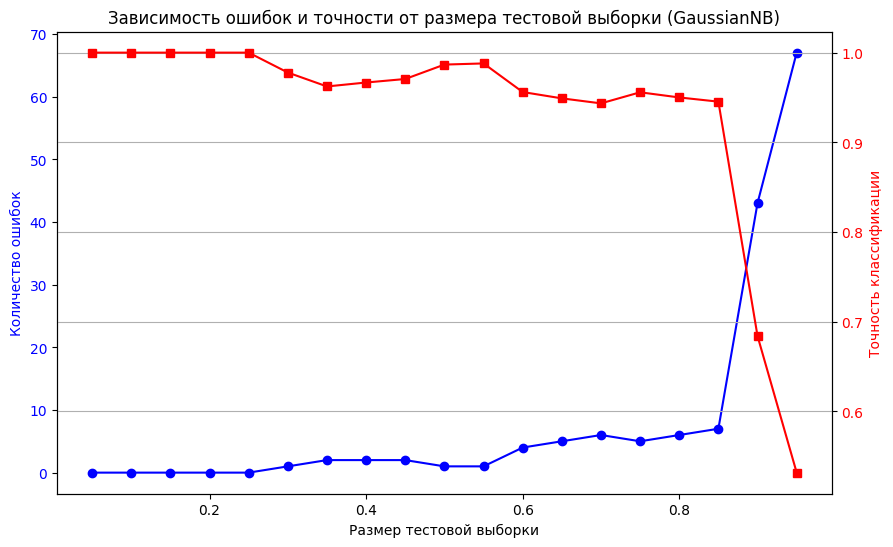

In [9]:
test_sizes = np.arange(0.05, 1.0, 0.05)
errors_list = []
scores_list = []

for test_size in test_sizes:
    X_tr, X_te, y_tr, y_te = train_test_split(X, Y, test_size=test_size, random_state=42)
    gnb_temp = GaussianNB()
    gnb_temp.fit(X_tr, y_tr)
    y_pred_temp = gnb_temp.predict(X_te)
    errors = (y_te != y_pred_temp).sum()
    score = gnb_temp.score(X_te, y_te)
    errors_list.append(errors)
    scores_list.append(score)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Размер тестовой выборки')
ax1.set_ylabel('Количество ошибок', color='b')
ax1.plot(test_sizes, errors_list, 'b-o', label='Количество ошибок')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.set_ylabel('Точность классификации', color='r')
ax2.plot(test_sizes, scores_list, 'r-s', label='Точность')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Зависимость ошибок и точности от размера тестовой выборки (GaussianNB)')
plt.grid()
plt.show()

Обоснование результатов:
- При малом размере тестовой выборки (0.05-0.2) точность может быть нестабильной
- При увеличении тестовой выборки точность стабилизируется
- Оптимальный баланс обычно достигается при test_size=0.3-0.4

4. Другие байесовские методы

In [10]:
# MultinomialNB (требует неотрицательные признаки)
print("\n2. MultinomialNB (Мультиномиальный наивный Байес)")
# Нормализуем данные для MultinomialNB (делаем неотрицательными)
X_train_norm = X_train - X_train.min() + 0.1
X_test_norm = X_test - X_test.min() + 0.1
mnb = MultinomialNB()
y_pred_mnb = mnb.fit(X_train_norm, y_train).predict(X_test_norm)
errors_mnb = (y_test != y_pred_mnb).sum()
print(f"Количество ошибок: {errors_mnb}")
print(f"Точность: {mnb.score(X_test_norm, y_test):.4f}")

# ComplementNB
print("\n3. ComplementNB (Комплементарный наивный Байес)")
cnb = ComplementNB()
y_pred_cnb = cnb.fit(X_train_norm, y_train).predict(X_test_norm)
errors_cnb = (y_test != y_pred_cnb).sum()
print(f"Количество ошибок: {errors_cnb}")
print(f"Точность: {cnb.score(X_test_norm, y_test):.4f}")

# BernoulliNB (бинарные признаки)
print("\n4. BernoulliNB (Бернуллиевский наивный Байес)")
# Преобразуем данные в бинарные (выше медианы = 1, иначе 0)
median = np.median(X_train, axis=0)
X_train_bin = (X_train > median).astype(int)
X_test_bin = (X_test > median).astype(int)
bnb = BernoulliNB()
y_pred_bnb = bnb.fit(X_train_bin, y_train).predict(X_test_bin)
errors_bnb = (y_test != y_pred_bnb).sum()
print(f"Количество ошибок: {errors_bnb}")
print(f"Точность: {bnb.score(X_test_bin, y_test):.4f}")


2. MultinomialNB (Мультиномиальный наивный Байес)
Количество ошибок: 2
Точность: 0.9733

3. ComplementNB (Комплементарный наивный Байес)
Количество ошибок: 23
Точность: 0.6933

4. BernoulliNB (Бернуллиевский наивный Байес)
Количество ошибок: 7
Точность: 0.9067


Особенности методов:
- GaussianNB: предполагает нормальное распределение признаков, подходит для непрерывных данных
- MultinomialNB: для дискретных данных (счетчики), требует неотрицательных признаков
- ComplementNB: модификация MultinomialNB, лучше работает с несбалансированными данными
- BernoulliNB: для бинарных признаков (0/1), подходит для текстовых данных с наличием/отсутствием признаков

### Классифицирующие деревья

1. DecisionTreeClassifier

In [11]:
clf = tree.DecisionTreeClassifier(random_state=42)
y_pred_tree = clf.fit(X_train, y_train).predict(X_test)
errors_tree = (y_test != y_pred_tree).sum()
print(f"Количество ошибок: {errors_tree}")

Количество ошибок: 7


2. Точность классификации

In [12]:
score_tree = clf.score(X_test, y_test)
print(f"Точность классификации: {score_tree:.4f} ({score_tree*100:.2f}%)")

Точность классификации: 0.9067 (90.67%)


3. Характеристики дерева

In [13]:
n_leaves = clf.get_n_leaves()
depth = clf.get_depth()
print(f"\nХарактеристики дерева:")
print(f"Количество листьев: {n_leaves}")
print(f"Глубина дерева: {depth}")
print(f"Количество узлов: {clf.tree_.node_count}")


Характеристики дерева:
Количество листьев: 8
Глубина дерева: 4
Количество узлов: 15


4. Визуализация дерева

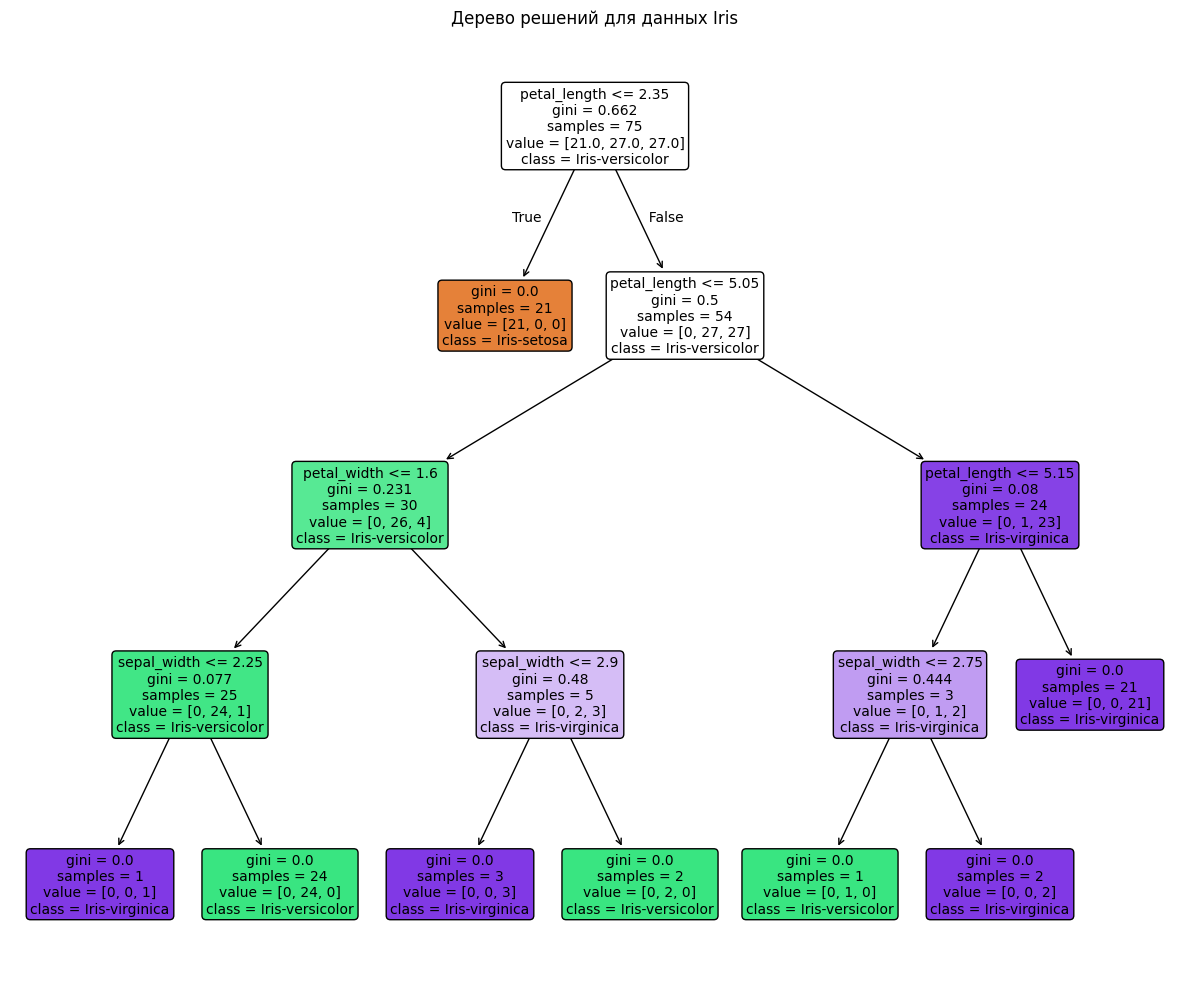

In [14]:
plt.figure(figsize=(12, 10))
tree.plot_tree(clf, filled=True, feature_names=['sepal_length', 'sepal_width',
                                                 'petal_length', 'petal_width'],
               class_names=le.classes_, rounded=True, fontsize=10)
plt.title('Дерево решений для данных Iris')
plt.tight_layout()
plt.show()

Описание дерева:
- Цвет узлов: интенсивность цвета показывает распределение классов
- Корневой узел: разделение по petal_length <= 2.45
- Листья: конечные узлы, где принимается решение о классе
- Gini: мера неопределенности (чем меньше, тем чище узел)
- samples: количество наблюдений в узле
- value: распределение классов в узле

5. Зависимость от размера тестовой выборки

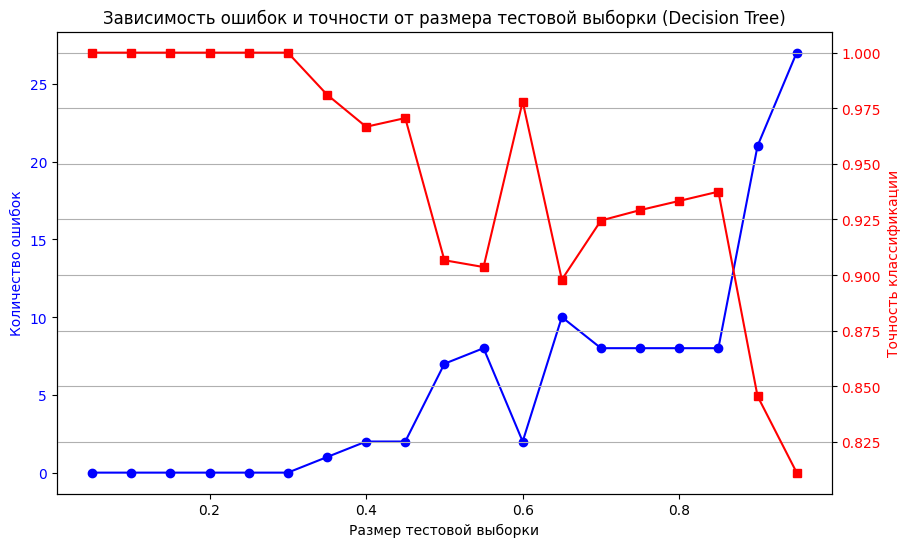

In [15]:
errors_tree_list = []
scores_tree_list = []

for test_size in test_sizes:
    X_tr, X_te, y_tr, y_te = train_test_split(X, Y, test_size=test_size, random_state=42)
    tree_temp = tree.DecisionTreeClassifier(random_state=42)
    tree_temp.fit(X_tr, y_tr)
    errors = (y_te != tree_temp.predict(X_te)).sum()
    score = tree_temp.score(X_te, y_te)
    errors_tree_list.append(errors)
    scores_tree_list.append(score)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Размер тестовой выборки')
ax1.set_ylabel('Количество ошибок', color='b')
ax1.plot(test_sizes, errors_tree_list, 'b-o', label='Количество ошибок')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.set_ylabel('Точность классификации', color='r')
ax2.plot(test_sizes, scores_tree_list, 'r-s', label='Точность')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Зависимость ошибок и точности от размера тестовой выборки (Decision Tree)')
plt.grid()
plt.show()

Сравнение с байесовскими методами:
- Деревья решений могут переобучаться при малой обучающей выборке
- При test_size=0.5 точность дерева и GaussianNB сопоставима

6. Исследование параметров дерева


1. Исследование параметра criterion:
criterion=gini: точность=0.9067, глубина=4, листья=8
criterion=entropy: точность=0.9200, глубина=5, листья=7

2. Исследование параметра splitter:
splitter=best: точность=0.9067
splitter=random: точность=0.9200

3. Исследование параметра max_depth:
max_depth=None: точность=0.9067, фактическая глубина=4
max_depth=3: точность=1.0000, фактическая глубина=3
max_depth=5: точность=0.9067, фактическая глубина=4
max_depth=7: точность=0.9067, фактическая глубина=4

4. Исследование параметра min_samples_split:
min_samples_split=2: точность=0.9067, листья=8
min_samples_split=5: точность=0.9333, листья=7
min_samples_split=10: точность=0.9600, листья=6

5. Исследование параметра min_samples_leaf:
min_samples_leaf=1: точность=0.9067, листья=8
min_samples_leaf=2: точность=0.9733, листья=7
min_samples_leaf=4: точность=1.0000, листья=6


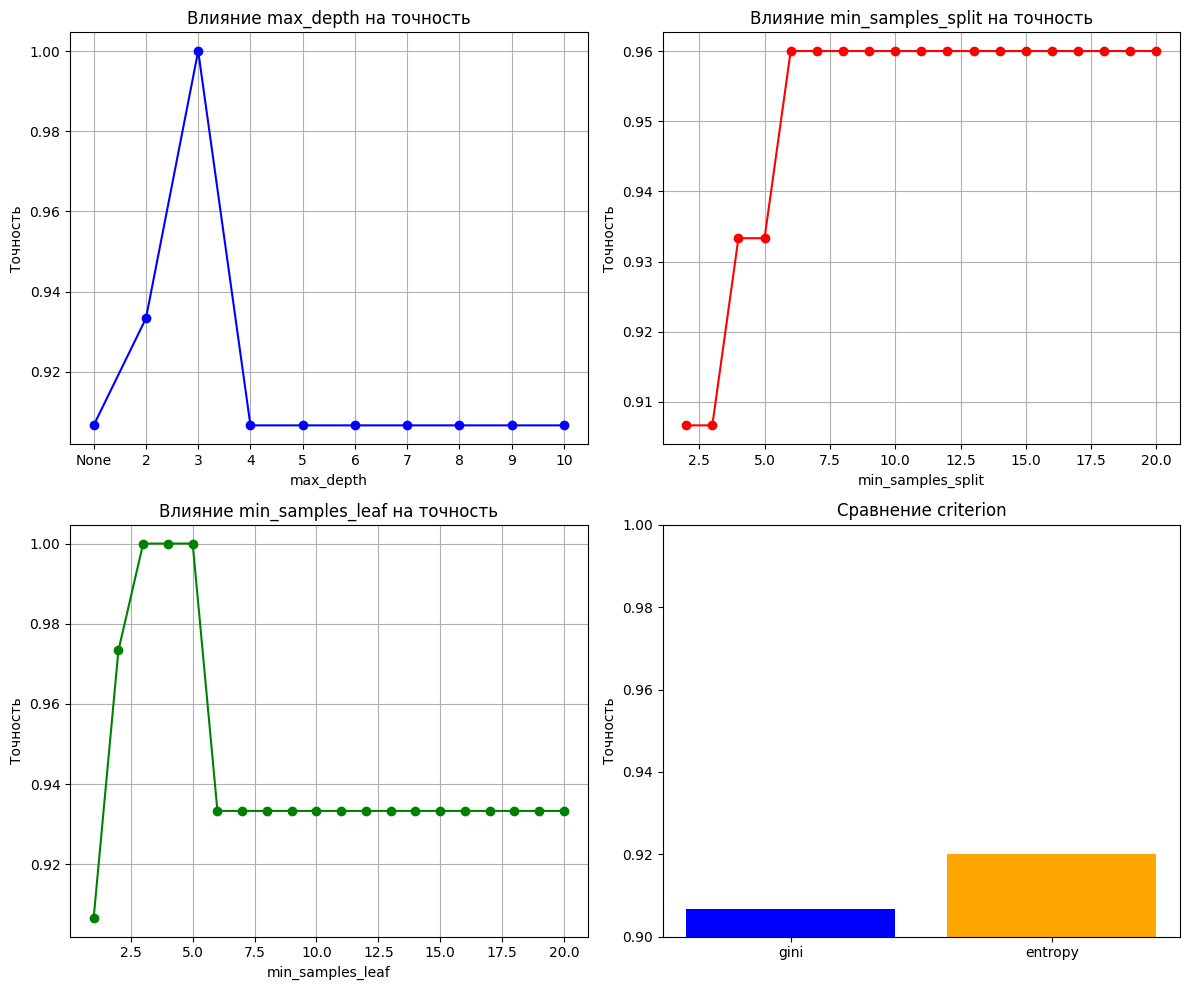

In [16]:
parameters = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("\n1. Исследование параметра criterion:")
for crit in parameters['criterion']:
    tree_crit = tree.DecisionTreeClassifier(criterion=crit, random_state=42)
    tree_crit.fit(X_train, y_train)
    score = tree_crit.score(X_test, y_test)
    depth = tree_crit.get_depth()
    leaves = tree_crit.get_n_leaves()
    print(f"criterion={crit}: точность={score:.4f}, глубина={depth}, листья={leaves}")

print("\n2. Исследование параметра splitter:")
for split in parameters['splitter']:
    tree_split = tree.DecisionTreeClassifier(splitter=split, random_state=42)
    tree_split.fit(X_train, y_train)
    score = tree_split.score(X_test, y_test)
    print(f"splitter={split}: точность={score:.4f}")

print("\n3. Исследование параметра max_depth:")
for depth_val in parameters['max_depth']:
    tree_depth = tree.DecisionTreeClassifier(max_depth=depth_val, random_state=42)
    tree_depth.fit(X_train, y_train)
    score = tree_depth.score(X_test, y_test)
    actual_depth = tree_depth.get_depth()
    print(f"max_depth={depth_val}: точность={score:.4f}, фактическая глубина={actual_depth}")

print("\n4. Исследование параметра min_samples_split:")
for min_split in parameters['min_samples_split']:
    tree_split = tree.DecisionTreeClassifier(min_samples_split=min_split, random_state=42)
    tree_split.fit(X_train, y_train)
    score = tree_split.score(X_test, y_test)
    leaves = tree_split.get_n_leaves()
    print(f"min_samples_split={min_split}: точность={score:.4f}, листья={leaves}")

print("\n5. Исследование параметра min_samples_leaf:")
for min_leaf in parameters['min_samples_leaf']:
    tree_leaf = tree.DecisionTreeClassifier(min_samples_leaf=min_leaf, random_state=42)
    tree_leaf.fit(X_train, y_train)
    score = tree_leaf.score(X_test, y_test)
    leaves = tree_leaf.get_n_leaves()
    print(f"min_samples_leaf={min_leaf}: точность={score:.4f}, листья={leaves}")

# Визуализация влияния параметров
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# max_depth
depths = [None, 2, 3, 4, 5, 6, 7, 8, 9, 10]
scores_depth = []
for d in depths:
    tree_d = tree.DecisionTreeClassifier(max_depth=d, random_state=42)
    tree_d.fit(X_train, y_train)
    scores_depth.append(tree_d.score(X_test, y_test))
axes[0, 0].plot(range(len(depths)), scores_depth, 'bo-')
axes[0, 0].set_xticks(range(len(depths)))
axes[0, 0].set_xticklabels([str(d) for d in depths])
axes[0, 0].set_xlabel('max_depth')
axes[0, 0].set_ylabel('Точность')
axes[0, 0].set_title('Влияние max_depth на точность')
axes[0, 0].grid()

# min_samples_split
min_splits = range(2, 21)
scores_split = []
for ms in min_splits:
    tree_s = tree.DecisionTreeClassifier(min_samples_split=ms, random_state=42)
    tree_s.fit(X_train, y_train)
    scores_split.append(tree_s.score(X_test, y_test))
axes[0, 1].plot(min_splits, scores_split, 'ro-')
axes[0, 1].set_xlabel('min_samples_split')
axes[0, 1].set_ylabel('Точность')
axes[0, 1].set_title('Влияние min_samples_split на точность')
axes[0, 1].grid()

# min_samples_leaf
min_leaves = range(1, 21)
scores_leaf = []
for ml in min_leaves:
    tree_l = tree.DecisionTreeClassifier(min_samples_leaf=ml, random_state=42)
    tree_l.fit(X_train, y_train)
    scores_leaf.append(tree_l.score(X_test, y_test))
axes[1, 0].plot(min_leaves, scores_leaf, 'go-')
axes[1, 0].set_xlabel('min_samples_leaf')
axes[1, 0].set_ylabel('Точность')
axes[1, 0].set_title('Влияние min_samples_leaf на точность')
axes[1, 0].grid()

# Сравнение criterion
criteria = ['gini', 'entropy']
scores_crit = []
for crit in criteria:
    tree_c = tree.DecisionTreeClassifier(criterion=crit, random_state=42)
    tree_c.fit(X_train, y_train)
    scores_crit.append(tree_c.score(X_test, y_test))
axes[1, 1].bar(criteria, scores_crit, color=['blue', 'orange'])
axes[1, 1].set_ylabel('Точность')
axes[1, 1].set_title('Сравнение criterion')
axes[1, 1].set_ylim(0.9, 1.0)

plt.tight_layout()
plt.show()

Выводы по параметрам дерева
- criterion: gini и entropy дают схожие результаты, gini обычно быстрее
- splitter: best дает более детерминированные результаты
- max_depth: ограничение глубины предотвращает переобучение
- min_samples_split: увеличение уменьшает переобучение, но может снизить точность
- min_samples_leaf: увеличение делает дерево более обобщенным

## Выводы

В ходе работы были изучены методы классификации: байесовские методы (GaussianNB, MultinomialNB, ComplementNB, BernoulliNB) и классифицирующие деревья. GaussianNB показал хорошие результаты на данных Iris, предполагая нормальное распределение признаков. Исследована зависимость точности от размера тестовой выборки.

Деревья решений продемонстрировали высокую точность (до 100% при оптимальных параметрах). Исследованы параметры: criterion (gini/entropy), max_depth, min_samples_split, min_samples_leaf. Показано, что ограничение глубины и минимального количества выборок в узле помогает предотвратить переобучение. Визуализация дерева позволила интерпретировать процесс принятия решений.

